Vetorizando textos... (Isso pode demorar um pouco)

=== RELATÓRIO DE CLASSIFICAÇÃO NLP ===
               precision    recall  f1-score   support

         ADHD       0.86      0.91      0.88       401
      Anxiety       0.73      0.79      0.76       384
       Autism       0.80      0.78      0.79       299
          BPD       0.82      0.80      0.81       324
      Bipolar       0.77      0.73      0.75       365
   Depression       0.60      0.67      0.64       287
schizophrenia       0.80      0.58      0.67       195

     accuracy                           0.77      2255
    macro avg       0.77      0.75      0.76      2255
 weighted avg       0.77      0.77      0.77      2255



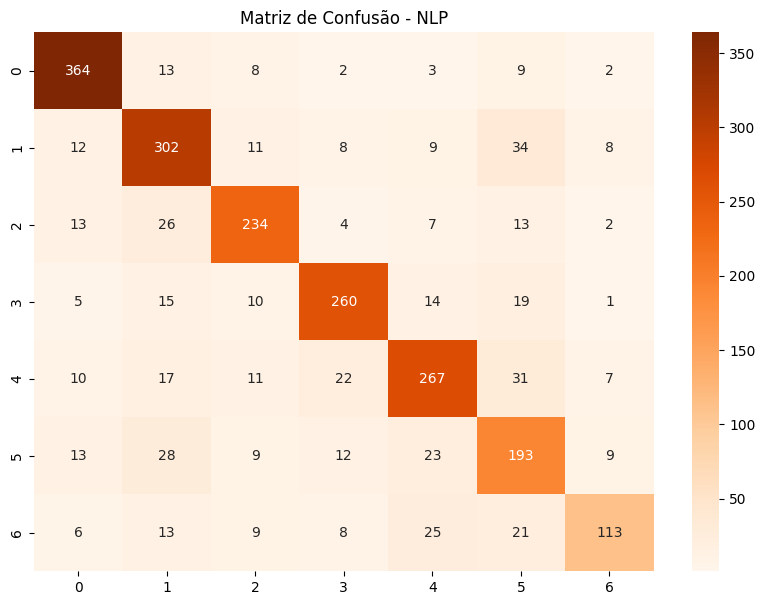

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Carregar os Dados
df_text = pd.read_csv('../data/Mental Health Disorder Detection Dataset.csv')

# 2. Ajuste de Colunas (Corrigindo o erro anterior)
coluna_texto = 'body'     
coluna_alvo = 'category'  

# Limpeza: remover nulos
df_text = df_text.dropna(subset=[coluna_texto, coluna_alvo])

# --- DICA DE TCC: O PROBLEMA DO "OTHER" ---
# Se quiser focar apenas nos diagnósticos claros (ADHD e Anxiety), 
# você poderia filtrar o 'Other' fora. Mas vamos manter para ver o que acontece.
# ------------------------------------------

X_text = df_text[coluna_texto]
y_text = df_text[coluna_alvo]

# 3. Divisão Treino/Teste
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_text, y_text, test_size=0.2, random_state=42, stratify=y_text
)

# 4. TF-IDF (Transformando o texto em números)
print("Vetorizando textos... (Isso pode demorar um pouco)")
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train_t)
X_test_vec = vectorizer.transform(X_test_t)

# 5. Modelo
modelo_nlp = LogisticRegression(max_iter=1000, random_state=42)
modelo_nlp.fit(X_train_vec, y_train_t)

# 6. Resultados
y_pred_t = modelo_nlp.predict(X_test_vec)

print("\n=== RELATÓRIO DE CLASSIFICAÇÃO NLP ===")
print(classification_report(y_test_t, y_pred_t))

# 7. Matriz de Confusão
plt.figure(figsize=(10,7))
sns.heatmap(confusion_matrix(y_test_t, y_pred_t), annot=True, fmt='d', cmap='Oranges')
plt.title('Matriz de Confusão - NLP')
plt.show()